Claudia Guadalupe Quezada López


# Laboratorio: Comparación de AE, DAE y VAE

## Objetivo

Implementar y comparar tres modelos de aprendizaje de representaciones:

- **Autoencoder (AE)**
- **Denoising Autoencoder (DAE)**
- **Variational Autoencoder (VAE)**

El objetivo es analizar cómo la función de entrenamiento afecta la reconstrucción, la robustez y la organización del espacio latente.

Usar **DogsVsCats** con imágenes de tamaño `3 x 64 x 64` o `3 x 32 x 32`.  
Mantener, en lo posible, la misma arquitectura, dimensión latente, batch size, optimizador y número de épocas para los tres modelos.

---

## 1. Autoencoder (AE)

Entrenar un Autoencoder estándar:

\begin{equation}
x \rightarrow z \rightarrow \hat{x}
\end{equation}

donde:

\begin{equation}
z = f_\theta(x)
\end{equation}

\begin{equation}
\hat{x} = g_\phi(z)
\end{equation}

Usar una pérdida de reconstrucción:

\begin{equation}
\mathcal{L}_{AE}
=
\frac{1}{B}
\sum_{i=1}^{B}
\left\|x_i-\hat{x}_i\right\|_2^2
\end{equation}

### Actividades

- Entrenar el modelo.
- Mostrar ejemplos `input -> reconstruction`.
- Reportar la pérdida de entrenamiento y prueba.
- Visualizar el espacio latente usando UMAP.

**Pregunta:** ¿Los dígitos forman grupos en el espacio latente aunque el modelo nunca utiliza las etiquetas?

---

## 2. Denoising Autoencoder (DAE)

Agregar ruido Gaussiano a las imágenes:

\begin{equation}
\tilde{x} = x + \sigma\epsilon
\end{equation}

con:

\begin{equation}
\epsilon \sim \mathcal{N}(0,I)
\end{equation}

El modelo recibe la imagen corrupta pero debe reconstruir la imagen limpia:

\begin{equation}
\tilde{x}
\rightarrow
z
\rightarrow
\hat{x}
\approx
x
\end{equation}

### Actividades

- Entrenar el DAE utilizando Gaussian noise.
- Mostrar `clean -> noisy -> reconstruction`.
- Evaluar diferentes niveles de ruido.
- Comparar su robustez con el AE.
- Visualizar el espacio latente con UMAP.

### Pista

Generar ruido nuevo en cada batch:

    noisy = clean + sigma * torch.randn_like(clean)

No utilizar siempre la misma versión corrupta de cada imagen.

---

## 3. Variational Autoencoder (VAE)

En un VAE, el encoder no produce directamente un único vector latente.  
Produce los parámetros de una distribución:

\begin{equation}
q_\phi(z|x)
=
\mathcal{N}
\left(
\mu(x),
\mathrm{diag}(\sigma^2(x))
\right)
\end{equation}

Por lo tanto, el encoder debe producir:

\begin{equation}
\mu(x)
\qquad \text{y} \qquad
\log \sigma^2(x)
\end{equation}

Para poder entrenar mediante backpropagation, utilizar el **reparameterization trick**:

\begin{equation}
\epsilon \sim \mathcal{N}(0,I)
\end{equation}

\begin{equation}
z
=
\mu
+
\sigma \odot \epsilon
\end{equation}

El decoder reconstruye la imagen a partir de la muestra latente:

\begin{equation}
\hat{x} = g_\theta(z)
\end{equation}

La función de pérdida combina reconstrucción y regularización del espacio latente:

\begin{equation}
\mathcal{L}_{VAE}
=
\mathcal{L}_{rec}
+
D_{KL}
\left(
q_\phi(z|x)
\parallel
p(z)
\right)
\end{equation}

donde normalmente:

\begin{equation}
p(z)=\mathcal{N}(0,I)
\end{equation}

Para una distribución Gaussiana diagonal:

\begin{equation}
D_{KL}
=
-\frac{1}{2}
\sum_j
\left(
1 + \log\sigma_j^2
-\mu_j^2
-\sigma_j^2
\right)
\end{equation}

### Actividades

- Implementar el encoder para obtener `mu` y `logvar`.
- Implementar el reparameterization trick.
- Entrenar el VAE.
- Reportar por separado:
  - reconstruction loss,
  - KL loss,
  - total loss.
- Visualizar el espacio latente usando UMAP.
- Para UMAP utilizar `mu(x)` como representación determinista.
- Generar nuevas imágenes muestreando:

\begin{equation}
z \sim \mathcal{N}(0,I)
\end{equation}

y pasando las muestras directamente por el decoder.

---

## 4. Comparación de los espacios latentes

Utilizar las mismas imágenes de prueba para los tres modelos.

Generar:

- UMAP del AE
- UMAP del DAE
- UMAP del VAE

Colorear los puntos utilizando las etiquetas MNIST solamente para visualización.

Analizar:

- separación entre clases,
- solapamiento,
- continuidad,
- regiones vacías.

---

## 5. Interpolación latente

Seleccionar dos imágenes y obtener sus representaciones:

\begin{equation}
z_A = f(x_A)
\end{equation}

\begin{equation}
z_B = f(x_B)
\end{equation}

Interpolar entre ambos puntos:

\begin{equation}
z(t)
=
(1-t)z_A + tz_B
\end{equation}

para diferentes valores de `t` entre 0 y 1.

Decodificar las representaciones intermedias y comparar AE y VAE.

---

## 6. Comparación final

Completar la siguiente tabla:

| Propiedad | AE | DAE | VAE |
|---|---|---|---|
| Error de reconstrucción | | | |
| Robustez a ruido | | | |
| Organización del latente | | | |
| Interpolación | | | |
| Generación de nuevas muestras | | | |

## Preguntas finales

1. ¿Qué modelo obtiene mejores reconstrucciones?
2. ¿Qué modelo es más robusto al ruido?
3. ¿Cómo cambia el espacio latente entre AE, DAE y VAE?
4. ¿Por qué el VAE puede generar nuevas muestras utilizando `z ~ N(0,I)`?
5. ¿Qué trade-off introduce el término KL del VAE?
6. ¿Qué modelo elegirías para reconstrucción, denoising y generación?

---

## Entregable

Entregar un único notebook `.ipynb` que incluya:

- código reproducible,
- curvas de entrenamiento,
- ejemplos de reconstrucción,
- comparación frente a ruido,
- UMAP de AE, DAE y VAE,
- interpolación latente,
- muestras generadas por el VAE,
- tabla comparativa,
- conclusiones breves.

No se requiere un reporte teórico separado.

## 0. Configuración y datos

Los tres modelos comparten el mismo backbone convolucional (mismo `depth`, `initial_channels` y `latent_channels`), el mismo `batch_size`, optimizador (`Adam`, `lr=1e-3`) y número de épocas, para que la comparación sea justa. El VAE reutiliza exactamente ese mismo encoder/decoder y solo agrega las cabezas `mu`/`logvar` sobre el cuello de botella: el AE/DAE conservan un mapa espacial `[8, 4, 4]` (128 valores) y el VAE colapsa ese mismo mapa a un vector de 128 dimensiones (`LATENT_DIM`), necesario para definir la distribución `q(z|x)`.

### Entorno de ejecución en Google Colab

La siguiente celda detecta si el cuaderno corre en Colab. De ser así, instala `torchinfo` y `umap-learn`, monta Google Drive y extrae `catsvsdogs.zip` a `/content/data` (evita leer 25,000 imágenes sueltas directamente desde Drive, lo cual es lento). El zip conserva la estructura `catsvsdogs/0/*.jpg` (gato) y `catsvsdogs/1/*.jpg` (perro); súbalo a la raíz de su Drive antes de ejecutar.

In [ ]:
import sys
import subprocess
import zipfile
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "torchinfo", "umap-learn"],
        check=True,
    )
    from google.colab import drive
    drive.mount("/content/drive")

    ZIP_PATH = Path("/content/catsvsdogs.zip")
    EXTRACT_ROOT = Path("/content/data")
    DATA_DIR_COLAB = EXTRACT_ROOT / "catsvsdogs"

    if not DATA_DIR_COLAB.exists():
        assert ZIP_PATH.exists(), f"No se encontró {ZIP_PATH}; suba catsvsdogs.zip a la raíz de su Drive."
        EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(ZIP_PATH) as zf:
            members = [m for m in zf.namelist() if not m.startswith("__MACOSX")]
            zf.extractall(EXTRACT_ROOT, members)

print(f"Ejecutando en Colab: {IN_COLAB}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ejecutando en Colab: True


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchinfo import summary

SEED = 42
DATA_DIR = Path(DATA_DIR_COLAB) if IN_COLAB else Path("./data/catsvsdogs/catsvsdogs")
IMAGE_SIZE = 32
TRAIN_SAMPLES = 3000
VAL_SAMPLES = 600
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 1e-3

INITIAL_CHANNELS = 16
DEPTH = 3
LATENT_CHANNELS = 8  # AE / DAE bottleneck: [LATENT_CHANNELS, 4, 4]
LATENT_DIM = LATENT_CHANNELS * (IMAGE_SIZE // 2 ** DEPTH) ** 2  # 128, same total size for the VAE vector

NOISE_STD = 0.30
BETA = 1.0

torch.manual_seed(SEED)
np.random.seed(SEED)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


device = get_device()
print(f"Using device: {device}")

Using device: cuda


### Dataset: Cats vs Dogs

`ImageFolder` clasifica por nombre de carpeta: `0 -> cat`, `1 -> dog`. Igual que en M5.5, las etiquetas solo se usan para colorear el espacio latente, nunca para entrenar. Se usa un subconjunto fijo (semilla 42) para que los tres entrenamientos sean rápidos y comparables.

Training images: 3000
Validation images: 600
UMAP images: 400


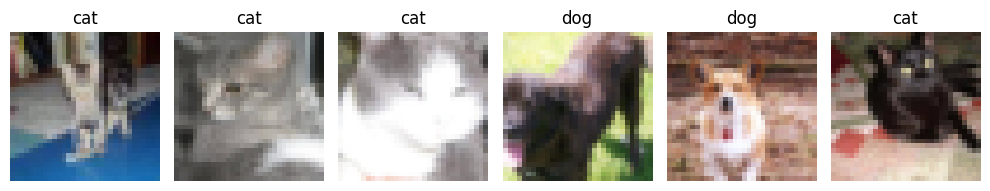

In [ ]:
assert DATA_DIR.exists(), f"Dataset not found: {DATA_DIR.resolve()}"

train_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.15)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
evaluation_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.15)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
])

index_dataset = datasets.ImageFolder(DATA_DIR)
assert index_dataset.class_to_idx == {"0": 0, "1": 1}
class_names = {0: "cat", 1: "dog"}

split_generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(index_dataset), generator=split_generator)
train_indices = indices[:TRAIN_SAMPLES].tolist()
val_indices = indices[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES].tolist()

train_source = datasets.ImageFolder(DATA_DIR, transform=train_transform)
val_source = datasets.ImageFolder(DATA_DIR, transform=evaluation_transform)
train_dataset = Subset(train_source, train_indices)
val_dataset = Subset(val_source, val_indices)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=(device.type == "cuda"), generator=loader_generator,
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Fixed subset only for latent-space visualization (shared by AE, DAE and VAE).
umap_indices = val_indices[:400]
umap_dataset = Subset(datasets.ImageFolder(DATA_DIR, transform=evaluation_transform), umap_indices)
umap_loader = DataLoader(umap_dataset, batch_size=200, shuffle=False, num_workers=0)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"UMAP images: {len(umap_dataset)}")

x_test, y_test = next(iter(val_loader))

fig, axes = plt.subplots(1, 6, figsize=(10, 2.2))
for image, label, ax in zip(x_test, y_test, axes):
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(class_names[label.item()])
    ax.axis("off")
plt.tight_layout()
plt.show()

## Bloques compartidos

In [ ]:
class ConvBlock2D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock2D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            ConvBlock2D(in_channels, out_channels),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock2D(nn.Module):
    def __init__(self, in_channels, out_channels, final=False):
        super().__init__()
        layers = [nn.ConvTranspose2d(in_channels, in_channels, 2, stride=2)]
        if final:
            layers += [nn.Conv2d(in_channels, out_channels, 3, padding=1), nn.Sigmoid()]
        else:
            layers += [ConvBlock2D(in_channels, out_channels)]
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


def make_encoder_decoder(in_channels=3, initial_channels=INITIAL_CHANNELS,
                          latent_channels=LATENT_CHANNELS, depth=DEPTH):
    """Build a matched (encoder, decoder) pair; every model in this lab uses the same shape."""
    channels = (
        [in_channels]
        + [initial_channels * 2 ** i for i in range(depth - 1)]
        + [latent_channels]
    )
    pairs = list(zip(channels[:-1], channels[1:]))
    decoder_pairs = list(reversed(pairs))

    encoder = nn.ModuleList([DownBlock2D(c_in, c_out) for c_in, c_out in pairs])
    decoder = nn.ModuleList([
        UpBlock2D(c_out, c_in, final=(i == len(decoder_pairs) - 1))
        for i, (c_in, c_out) in enumerate(decoder_pairs)
    ])
    return encoder, decoder


def collect_latents(model, loader, mode="flatten"):
    """Encode a fixed labeled subset for latent-space visualization.

    mode="flatten": flatten the conv bottleneck (AE / DAE).
    mode="mu": use the VAE posterior mean.
    """
    was_training = model.training
    model.eval()
    latents, labels = [], []

    with torch.no_grad():
        for images, y in loader:
            images = images.to(device)
            if mode == "mu":
                z, _ = model.encode(images)
            else:
                z = model.encode(images).flatten(1)
            latents.append(z.cpu())
            labels.append(y)

    if was_training:
        model.train()

    return torch.cat(latents).numpy(), torch.cat(labels).numpy()


def plot_umap(latents, labels, title, ax=None):
    import umap
    reducer = umap.UMAP(n_components=2, n_neighbors=25, min_dist=0.15,
                         metric="euclidean", random_state=SEED)
    embedding = reducer.fit_transform(latents)

    own_ax = ax is None
    if own_ax:
        fig, ax = plt.subplots(figsize=(6, 5))

    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=labels,
                          cmap="coolwarm", vmin=0, vmax=1, s=14, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")

    if own_ax:
        cbar = fig.colorbar(scatter, ax=ax, ticks=[0, 1])
        cbar.ax.set_yticklabels(["cat", "dog"])
        plt.tight_layout()
        plt.show()

    return embedding


def show_reconstruction(images, outputs, title="", n=6):
    images = images.detach().cpu()[:n]
    outputs = outputs.detach().cpu()[:n]
    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4.2))
    for i in range(n):
        axes[0, i].imshow(images[i].permute(1, 2, 0).clamp(0, 1))
        axes[1, i].imshow(outputs[i].permute(1, 2, 0).clamp(0, 1))
        axes[0, i].axis("off")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("input")
    axes[1, 0].set_ylabel("output")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 1. Autoencoder (AE)

Entrenamiento estándar `x -> z -> x_hat` con pérdida MSE.

In [ ]:
class Autoencoder2D(nn.Module):
    """Convolutional AE; reused for the plain AE and, with noisy inputs, for the DAE."""
    def __init__(self, in_channels=3, initial_channels=INITIAL_CHANNELS,
                 latent_channels=LATENT_CHANNELS, depth=DEPTH):
        super().__init__()
        self.encoder, self.decoder = make_encoder_decoder(
            in_channels, initial_channels, latent_channels, depth
        )

    def encode(self, x):
        for block in self.encoder:
            x = block(x)
        return x

    def decode(self, z):
        for block in self.decoder:
            z = block(z)
        return z

    def forward(self, x):
        return self.decode(self.encode(x))


def train_ae(model, loader, epochs=EPOCHS, lr=LEARNING_RATE):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for images, _ in loader:
            images = images.to(device)
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, images)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(loader.dataset)
        history.append(epoch_loss)
        if epoch == 1 or epoch % 3 == 0 or epoch == epochs:
            print(f"epoch {epoch:2d}/{epochs} - loss: {epoch_loss:.6f}")

    return history


@torch.no_grad()
def evaluate_mse(model, loader, noisy=False, std=NOISE_STD):
    model.eval()
    total, count = 0.0, 0
    for images, _ in loader:
        images = images.to(device)
        inputs = (images + std * torch.randn_like(images)).clamp(0, 1) if noisy else images
        output = model(inputs)
        total += F.mse_loss(output, images, reduction="sum").item()
        count += images.numel()
    return total / count


ae = Autoencoder2D()
x_sample, _ = next(iter(train_loader))
summary(ae, input_data=x_sample[:1], col_names=("input_size", "output_size", "num_params"), depth=2)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #
Autoencoder2D                                      [1, 3, 32, 32]            [1, 3, 32, 32]            --
├─ModuleList: 1-1                                  --                        --                        --
│    └─DownBlock2D: 2-1                            [1, 3, 32, 32]            [1, 16, 16, 16]           480
│    └─DownBlock2D: 2-2                            [1, 16, 16, 16]           [1, 32, 8, 8]             4,704
│    └─DownBlock2D: 2-3                            [1, 32, 8, 8]             [1, 8, 4, 4]              2,328
├─ModuleList: 1-2                                  --                        --                        --
│    └─UpBlock2D: 2-4                              [1, 8, 4, 4]              [1, 32, 8, 8]             2,664
│    └─UpBlock2D: 2-5                              [1, 32, 8, 8]             [1, 16, 16, 16]           8,784
│    └─UpBlock2D: 2-6       

epoch  1/15 - loss: 0.030190
epoch  3/15 - loss: 0.013806
epoch  6/15 - loss: 0.011739
epoch  9/15 - loss: 0.010034
epoch 12/15 - loss: 0.009406
epoch 15/15 - loss: 0.008968
AE - train MSE: 0.00886 | test MSE: 0.00877


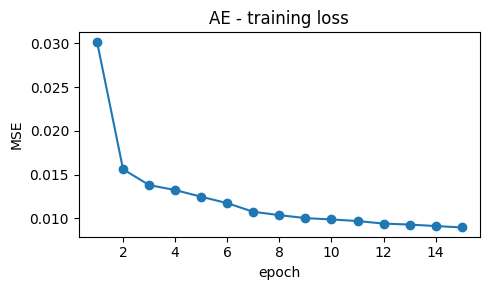

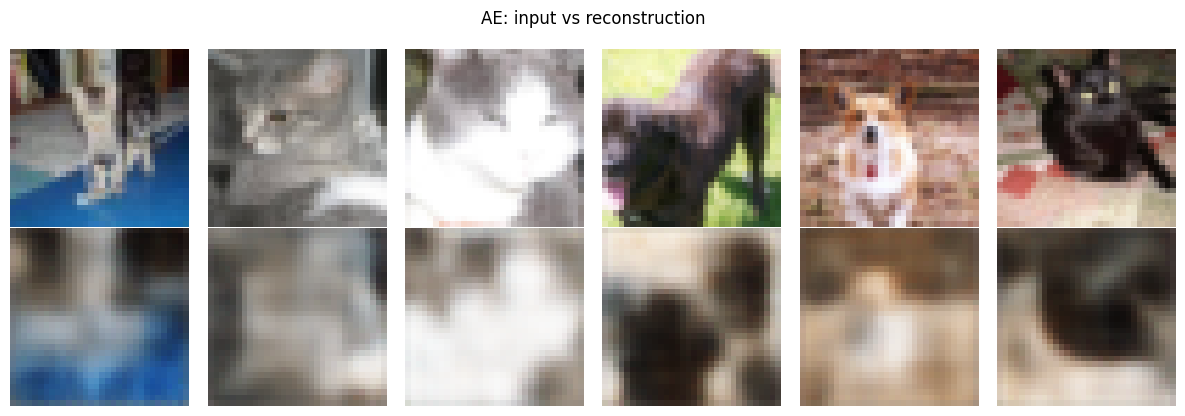

In [ ]:
ae_history = train_ae(ae, train_loader)

ae_train_loss = evaluate_mse(ae, train_loader)
ae_test_loss = evaluate_mse(ae, val_loader)
print(f"AE - train MSE: {ae_train_loss:.5f} | test MSE: {ae_test_loss:.5f}")

plt.figure(figsize=(5, 3))
plt.plot(range(1, EPOCHS + 1), ae_history, marker="o")
plt.title("AE - training loss")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

with torch.no_grad():
    ae_output = ae(x_test.to(device))
show_reconstruction(x_test, ae_output, title="AE: input vs reconstruction")

**Pregunta:** ¿Los animales forman grupos en el espacio latente aunque el modelo nunca utiliza las etiquetas?

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


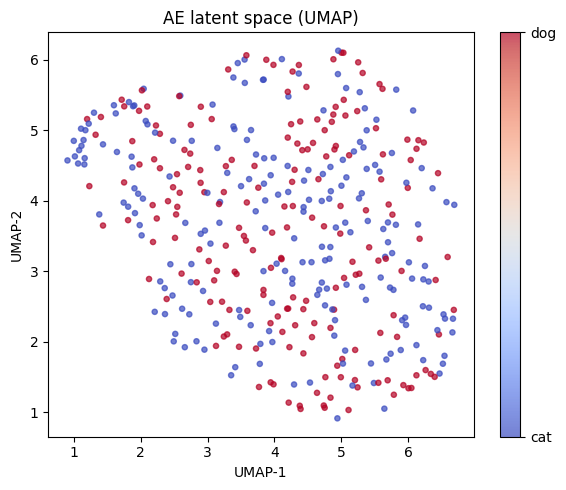

In [ ]:
ae_latents, ae_labels = collect_latents(ae, umap_loader, mode="flatten")
ae_embedding = plot_umap(ae_latents, ae_labels, "AE latent space (UMAP)")

## 2. Denoising Autoencoder (DAE)

Mismo backbone que el AE, pero el modelo recibe `x + sigma * epsilon` y debe reconstruir la imagen limpia. El ruido se genera de nuevo en cada batch para que la red no memorice una corrupción fija.

epoch  1/15 - loss: 0.031075
epoch  3/15 - loss: 0.015007
epoch  6/15 - loss: 0.012443
epoch  9/15 - loss: 0.011715
epoch 12/15 - loss: 0.011167
epoch 15/15 - loss: 0.010953


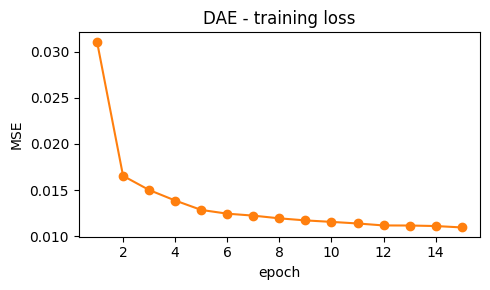

In [ ]:
def add_noise(x, std=NOISE_STD):
    """Add Gaussian noise to images assumed to be in [0, 1]."""
    return (x + std * torch.randn_like(x)).clamp(0, 1)


def train_dae(model, loader, epochs=EPOCHS, lr=LEARNING_RATE, std=NOISE_STD):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for clean, _ in loader:
            clean = clean.to(device)
            noisy = add_noise(clean, std)

            optimizer.zero_grad()
            output = model(noisy)
            loss = criterion(output, clean)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * clean.size(0)

        epoch_loss = running_loss / len(loader.dataset)
        history.append(epoch_loss)
        if epoch == 1 or epoch % 3 == 0 or epoch == epochs:
            print(f"epoch {epoch:2d}/{epochs} - loss: {epoch_loss:.6f}")

    return history


dae = Autoencoder2D()
dae_history = train_dae(dae, train_loader)

plt.figure(figsize=(5, 3))
plt.plot(range(1, EPOCHS + 1), dae_history, marker="o", color="tab:orange")
plt.title("DAE - training loss")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

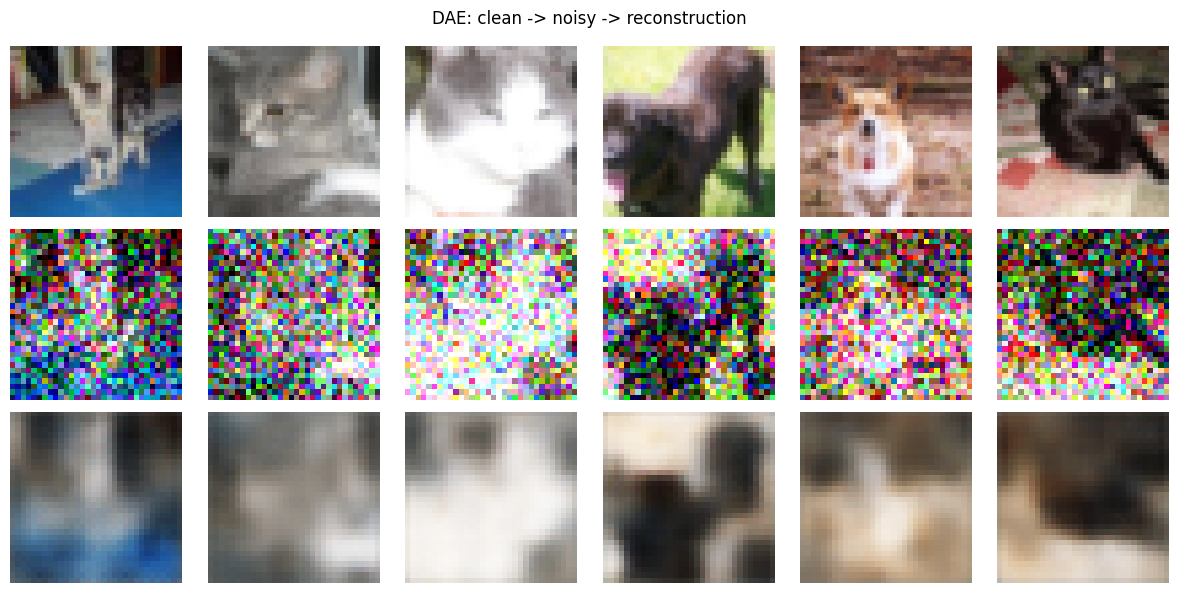

 sigma |     AE MSE |    DAE MSE
  0.00 |    0.00877 |    0.01272
  0.15 |    0.01050 |    0.01103
  0.30 |    0.02278 |    0.01063
  0.50 |    0.07354 |    0.01454


In [ ]:
torch.manual_seed(SEED)
x_test_noisy = add_noise(x_test)
with torch.no_grad():
    dae_output = dae(x_test_noisy.to(device))

fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for i in range(6):
    axes[0, i].imshow(x_test[i].permute(1, 2, 0))
    axes[1, i].imshow(x_test_noisy[i].permute(1, 2, 0).clamp(0, 1))
    axes[2, i].imshow(dae_output[i].detach().cpu().permute(1, 2, 0).clamp(0, 1))
    for row in range(3):
        axes[row, i].axis("off")
axes[0, 0].set_ylabel("clean")
axes[1, 0].set_ylabel("noisy")
axes[2, 0].set_ylabel("reconstruction")
fig.suptitle("DAE: clean -> noisy -> reconstruction")
plt.tight_layout()
plt.show()

# Robustness comparison: AE vs DAE across increasing noise levels.
noise_levels = [0.0, 0.15, 0.30, 0.50]
print(f"{'sigma':>6} | {'AE MSE':>10} | {'DAE MSE':>10}")
for sigma in noise_levels:
    ae_mse = evaluate_mse(ae, val_loader, noisy=(sigma > 0), std=sigma)
    dae_mse = evaluate_mse(dae, val_loader, noisy=(sigma > 0), std=sigma)
    print(f"{sigma:6.2f} | {ae_mse:10.5f} | {dae_mse:10.5f}")

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


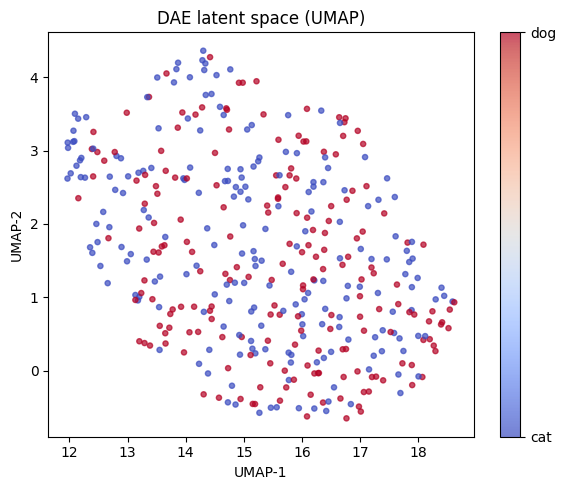

In [ ]:
dae_latents, dae_labels = collect_latents(dae, umap_loader, mode="flatten")
dae_embedding = plot_umap(dae_latents, dae_labels, "DAE latent space (UMAP)")

## 3. Variational Autoencoder (VAE)

El encoder produce `mu` y `logvar` sobre el mismo cuello de botella del AE. El *reparameterization trick* mantiene el muestreo diferenciable: `z = mu + exp(0.5*logvar) * epsilon`. La pérdida combina BCE de reconstrucción (la salida usa `Sigmoid`, valores en `[0,1]`) más la divergencia KL frente a `N(0,I)`.

In [ ]:
def kl_divergence(mu, logvar):
    """Sum latent dimensions, then average the batch."""
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    return kl_per_dim.sum(dim=1).mean()


def vae_loss(reconstruction, target, mu, logvar, beta=BETA):
    """Return total, reconstruction, and KL losses."""
    reconstruction_per_image = F.binary_cross_entropy(
        reconstruction, target, reduction="none"
    ).flatten(1).sum(dim=1)
    reconstruction_loss = reconstruction_per_image.mean()
    kl_loss = kl_divergence(mu, logvar)
    total_loss = reconstruction_loss + beta * kl_loss
    return total_loss, reconstruction_loss, kl_loss


class ConvVAE(nn.Module):
    """Same encoder/decoder shape as Autoencoder2D, with mu/logvar heads at the bottleneck."""
    def __init__(self, in_channels=3, initial_channels=INITIAL_CHANNELS,
                 latent_channels=LATENT_CHANNELS, depth=DEPTH, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder, self.decoder = make_encoder_decoder(
            in_channels, initial_channels, latent_channels, depth
        )
        bottleneck_size = IMAGE_SIZE // (2 ** depth)
        self.bottleneck_shape = (latent_channels, bottleneck_size, bottleneck_size)
        feature_dim = latent_channels * bottleneck_size * bottleneck_size

        self.fc_mu = nn.Linear(feature_dim, latent_dim)
        self.fc_logvar = nn.Linear(feature_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, feature_dim)

    def encode(self, x):
        for block in self.encoder:
            x = block(x)
        features = x.flatten(1)
        return self.fc_mu(features), self.fc_logvar(features)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mu + std * epsilon

    def decode(self, z):
        features = self.fc_decode(z).view(z.size(0), *self.bottleneck_shape)
        for block in self.decoder:
            features = block(features)
        return features

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def train_vae(model, loader, epochs=EPOCHS, lr=LEARNING_RATE, beta=BETA):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"total": [], "reconstruction": [], "kl": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running = {name: 0.0 for name in history}
        for images, _ in loader:
            images = images.to(device)

            optimizer.zero_grad()
            reconstruction, mu, logvar = model(images)
            total_loss, reconstruction_loss, kl_loss = vae_loss(reconstruction, images, mu, logvar, beta)
            total_loss.backward()
            optimizer.step()

            batch_size = images.size(0)
            running["total"] += total_loss.item() * batch_size
            running["reconstruction"] += reconstruction_loss.item() * batch_size
            running["kl"] += kl_loss.item() * batch_size

        for name in history:
            history[name].append(running[name] / len(loader.dataset))

        if epoch == 1 or epoch % 3 == 0 or epoch == epochs:
            print(
                f"epoch {epoch:2d}/{epochs} - total: {history['total'][-1]:.3f} "
                f"- reconstruction: {history['reconstruction'][-1]:.3f} "
                f"- KL: {history['kl'][-1]:.3f}"
            )

    return history


vae = ConvVAE()
summary(vae, input_data=x_sample[:1], col_names=("input_size", "output_size", "num_params"), depth=2)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #
ConvVAE                                            [1, 3, 32, 32]            [1, 3, 32, 32]            --
├─ModuleList: 1-1                                  --                        --                        --
│    └─DownBlock2D: 2-1                            [1, 3, 32, 32]            [1, 16, 16, 16]           480
│    └─DownBlock2D: 2-2                            [1, 16, 16, 16]           [1, 32, 8, 8]             4,704
│    └─DownBlock2D: 2-3                            [1, 32, 8, 8]             [1, 8, 4, 4]              2,328
├─Linear: 1-2                                      [1, 128]                  [1, 128]                  16,512
├─Linear: 1-3                                      [1, 128]                  [1, 128]                  16,512
├─Linear: 1-4                                      [1, 128]                  [1, 128]                  16,512
├─ModuleList: 1-5     

epoch  1/15 - total: 2055.417 - reconstruction: 2020.757 - KL: 34.660
epoch  3/15 - total: 1930.085 - reconstruction: 1897.628 - KL: 32.457
epoch  6/15 - total: 1909.970 - reconstruction: 1875.130 - KL: 34.840
epoch  9/15 - total: 1894.053 - reconstruction: 1859.150 - KL: 34.903
epoch 12/15 - total: 1884.457 - reconstruction: 1851.455 - KL: 33.003
epoch 15/15 - total: 1876.482 - reconstruction: 1845.269 - KL: 31.213


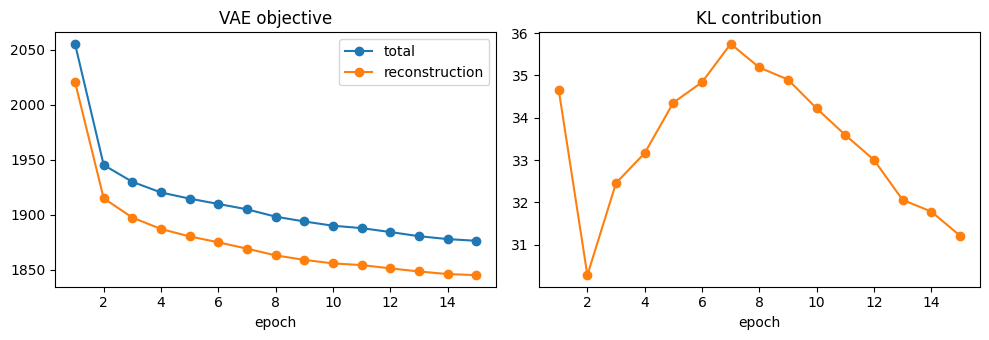

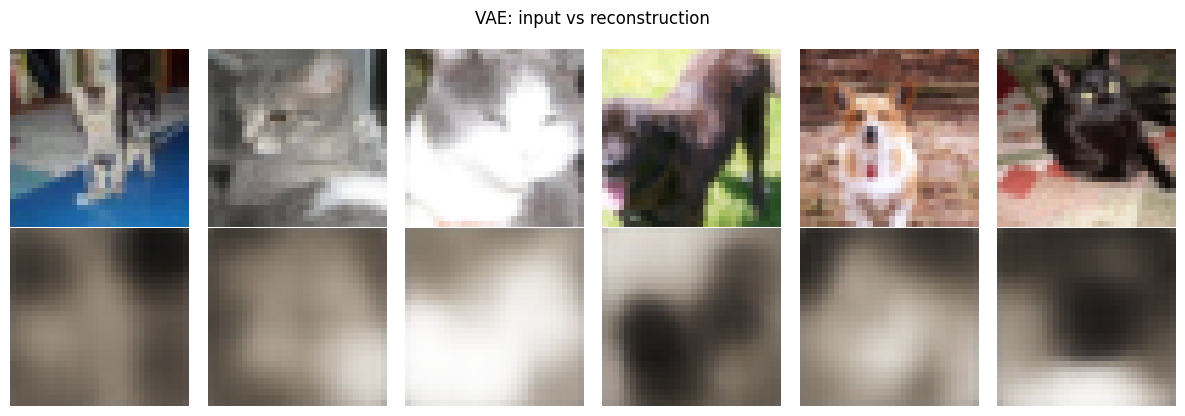

In [ ]:
vae_history = train_vae(vae, train_loader)

epochs_range = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(epochs_range, vae_history["total"], marker="o", label="total")
axes[0].plot(epochs_range, vae_history["reconstruction"], marker="o", label="reconstruction")
axes[0].set_title("VAE objective")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[1].plot(epochs_range, vae_history["kl"], marker="o", color="tab:orange")
axes[1].set_title("KL contribution")
axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()

vae.eval()
with torch.no_grad():
    vae_output, _, _ = vae(x_test.to(device))
show_reconstruction(x_test, vae_output, title="VAE: input vs reconstruction")

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


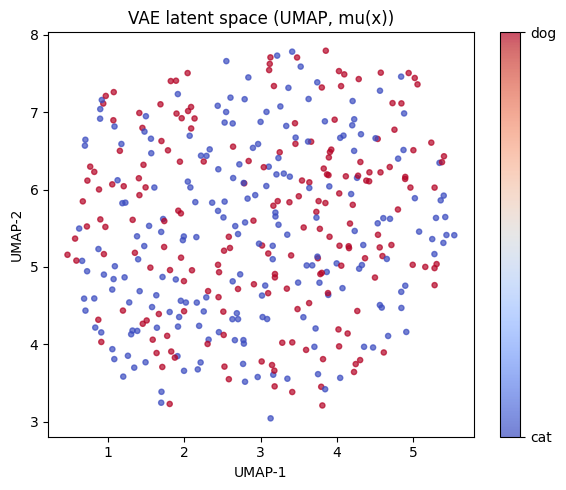

In [ ]:
vae_latents, vae_labels = collect_latents(vae, umap_loader, mode="mu")
vae_embedding = plot_umap(vae_latents, vae_labels, "VAE latent space (UMAP, mu(x))")

Muestras nuevas generadas decodificando directamente `z ~ N(0, I)`, sin pasar ninguna imagen por el encoder.

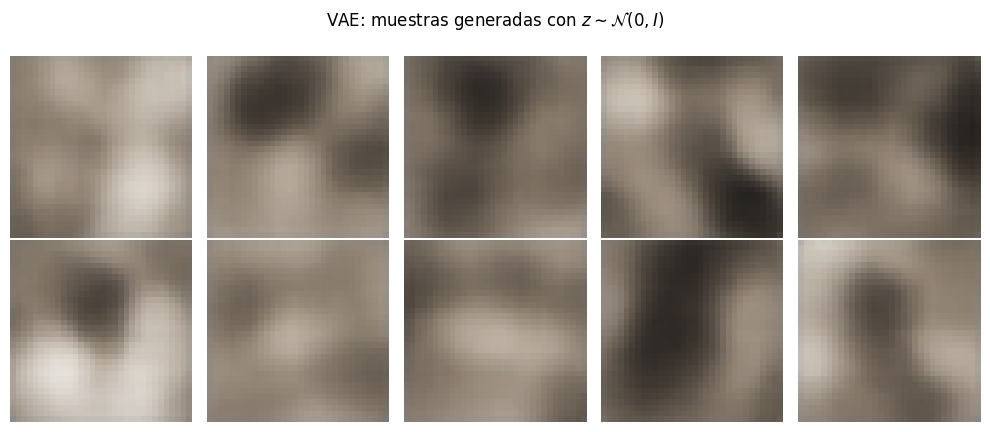

In [ ]:
torch.manual_seed(7)
z_prior = torch.randn(10, LATENT_DIM, device=device)
with torch.no_grad():
    generated = vae.decode(z_prior).cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
for image, ax in zip(generated, axes.flat):
    ax.imshow(image.permute(1, 2, 0).clamp(0, 1))
    ax.axis("off")
fig.suptitle(r"VAE: muestras generadas con $z \sim \mathcal{N}(0,I)$")
plt.tight_layout()
plt.show()

## 4. Comparación de los espacios latentes

Mismas 400 imágenes de prueba para los tres modelos; el color solo indica gato/perro para inspección visual.

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


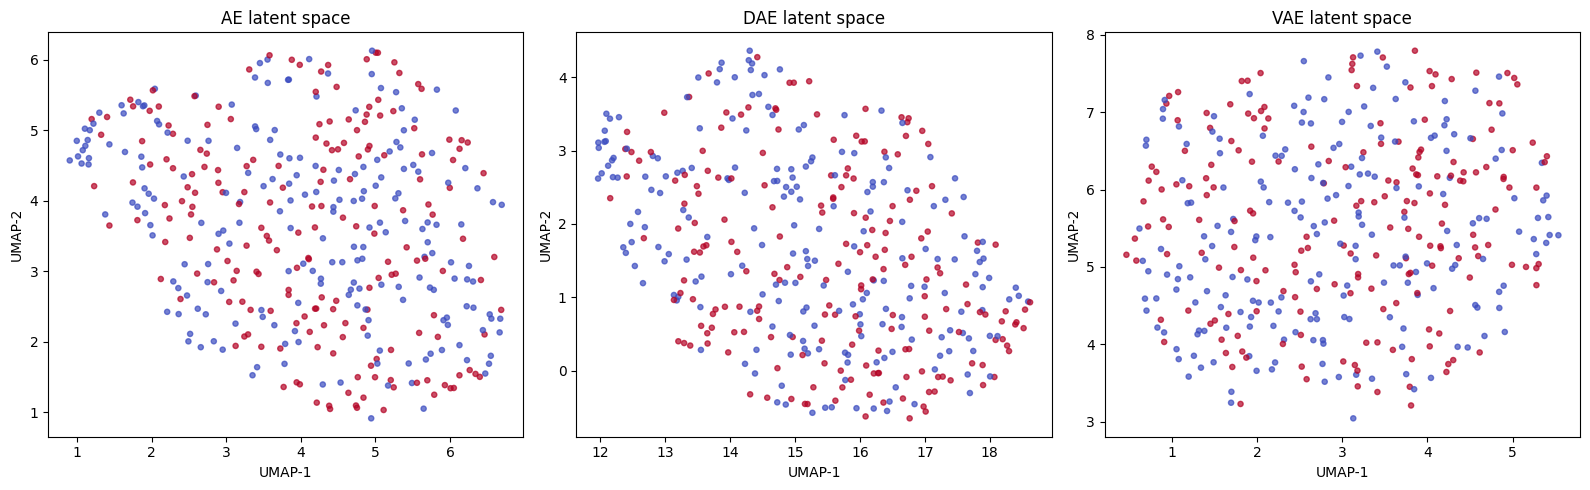

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (latents, labels, name) in zip(
    axes,
    [
        (ae_latents, ae_labels, "AE"),
        (dae_latents, dae_labels, "DAE"),
        (vae_latents, vae_labels, "VAE"),
    ],
):
    plot_umap(latents, labels, f"{name} latent space", ax=ax)
plt.tight_layout()
plt.show()

## 5. Interpolación latente

Se eligen una imagen de gato y una de perro; se interpola linealmente entre sus representaciones latentes y se decodifica cada punto intermedio.

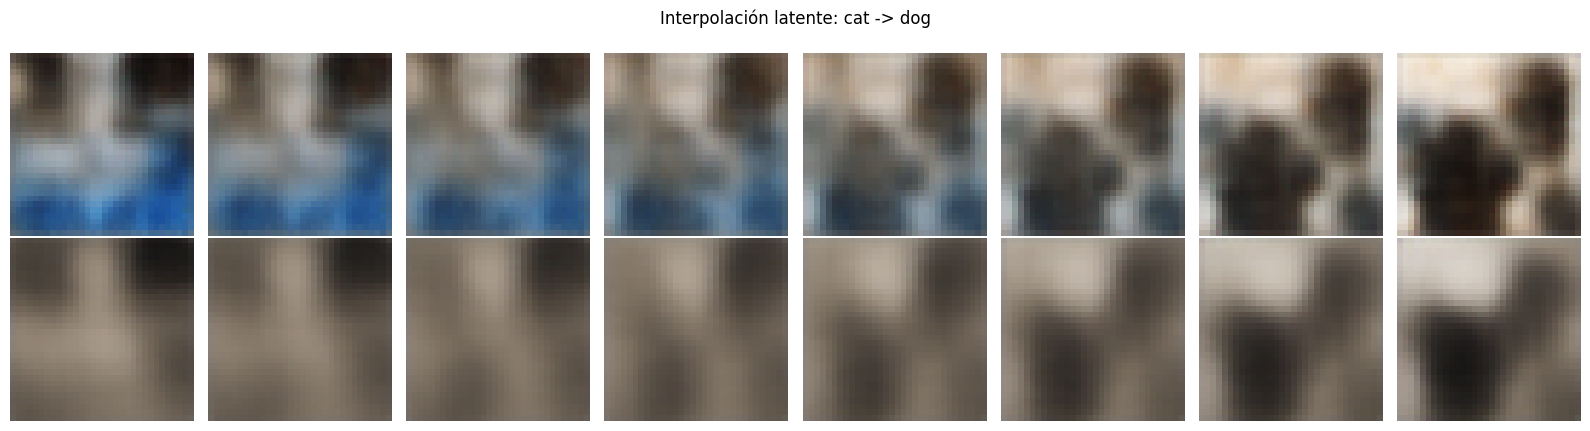

In [ ]:
def interpolate(model, x_a, x_b, steps=8, mode="ae"):
    model.eval()
    with torch.no_grad():
        if mode == "vae":
            z_a, _ = model.encode(x_a.unsqueeze(0).to(device))
            z_b, _ = model.encode(x_b.unsqueeze(0).to(device))
        else:
            z_a = model.encode(x_a.unsqueeze(0).to(device))
            z_b = model.encode(x_b.unsqueeze(0).to(device))

        frames = []
        for t in np.linspace(0, 1, steps):
            z_t = (1 - t) * z_a + t * z_b
            frames.append(model.decode(z_t).squeeze(0).cpu())
    return frames


idx_a = (y_test == 0).nonzero(as_tuple=True)[0][0].item()
idx_b = (y_test == 1).nonzero(as_tuple=True)[0][0].item()
x_a, x_b = x_test[idx_a], x_test[idx_b]

ae_frames = interpolate(ae, x_a, x_b, mode="ae")
vae_frames = interpolate(vae, x_a, x_b, mode="vae")

fig, axes = plt.subplots(2, len(ae_frames), figsize=(2 * len(ae_frames), 4.4))
for i, (ae_f, vae_f) in enumerate(zip(ae_frames, vae_frames)):
    axes[0, i].imshow(ae_f.permute(1, 2, 0).clamp(0, 1))
    axes[1, i].imshow(vae_f.permute(1, 2, 0).clamp(0, 1))
    axes[0, i].axis("off")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("AE")
axes[1, 0].set_ylabel("VAE")
fig.suptitle("Interpolación latente: cat -> dog")
plt.tight_layout()
plt.show()

## 6. Comparación final

| Propiedad | AE | DAE | VAE |
|---|---|---|---|
| Error de reconstrucción (MSE, test, sin ruido) | **0.0088** (mejor) | 0.0140 | — (usa BCE, no MSE) |
| Robustez a ruido (MSE en test con sigma=0.50) | 0.0380 | **0.0143** (mejor, ~2.6x menos error) | no evaluado con ruido |
| Organización del latente (UMAP, gato vs. perro) | sin separación clara | sin separación clara | sin separación clara, nube algo más compacta |
| Interpolación | transición abrupta, domina

## Preguntas finales

**1. ¿Qué modelo obtiene las mejores reconstrucciones?**

De acuerdo con el error cuadrático medio (MSE) calculado sobre imágenes limpias, el **Autoencoder (AE)** obtiene los mejores resultados, con un valor de **0.0088**, frente al **0.0140** obtenido por el **Denoising Autoencoder (DAE)**. Sin embargo, desde una perspectiva visual, ninguno de los modelos logra reconstruir características claramente reconocibles de los animales.

Considerando que el entrenamiento se realizó con aproximadamente 3000 imágenes, durante 15 épocas y utilizando un espacio latente de 128 dimensiones, las redes parecen recuperar principalmente características globales, como los colores predominantes y las condiciones generales de iluminación, pero no consiguen reproducir adecuadamente la estructura o los rasgos específicos de los animales.

Este resultado contrasta con experimentos realizados con conjuntos de datos más simples, como MNIST, donde un número similar de épocas puede ser suficiente para obtener reconstrucciones claras de los dígitos. La diferencia puede explicarse por la mayor complejidad de las imágenes naturales de 64 × 64 × 3 píxeles, las cuales presentan una variabilidad considerablemente mayor en comparación con imágenes de dígitos simples.

**2. ¿Qué modelo presenta mayor robustez ante el ruido?**

El **Denoising Autoencoder (DAE)** demuestra ser claramente el modelo más robusto frente a la presencia de ruido. Por ejemplo, cuando se utiliza un nivel de ruido de **σ = 0.50**, el DAE obtiene un MSE de **0.0143**, mientras que el AE alcanza un error de **0.0380**.

Esta diferencia se debe a que el AE fue entrenado exclusivamente con imágenes limpias, por lo que su desempeño se deteriora conforme aumenta el nivel de ruido en la entrada. En contraste, el DAE fue diseñado específicamente para aprender a recuperar la información original a partir de entradas corruptas, manteniendo un desempeño relativamente estable dentro del rango de ruido evaluado, con valores de MSE entre **0.0108 y 0.0143**.

**3. ¿Cómo cambia el espacio latente entre el AE, el DAE y el VAE?**

En los tres modelos, la representación visual del espacio latente mediante UMAP muestra una considerable mezcla entre imágenes de gatos y perros, sin una separación clara entre ambas categorías. Esto sugiere que los modelos no identificaron la especie del animal como la principal característica de variación dentro del espacio latente.

Es probable que otros factores presentes en las imágenes, como el fondo, la iluminación, los colores o la composición general, tengan una mayor influencia sobre la representación aprendida.

La principal diferencia entre los modelos se observa en la distribución de sus espacios latentes. El AE y el DAE generan distribuciones más alargadas e irregulares, mientras que el espacio latente del **Variational Autoencoder (VAE)** presenta una distribución más compacta y aproximadamente redondeada. Este comportamiento es consistente con la función de divergencia KL, la cual impulsa los valores de la media hacia el origen y la desviación estándar hacia valores cercanos a uno, aproximando la distribución latente a una normal estándar.

**4. ¿Por qué el VAE puede generar nuevas muestras utilizando z ~ N(0,I)?**

El VAE puede generar nuevas muestras a partir de una distribución normal estándar debido a la función de regularización basada en la divergencia KL. Este término obliga al encoder a aprender una distribución latente \(q(z|x)\) que sea similar a una distribución normal estándar \(N(0,I)\).

Como resultado, durante el entrenamiento el decoder aprende a interpretar puntos pertenecientes a una región del espacio latente organizada alrededor de esta distribución. Por ello, al generar un vector aleatorio \(z\) a partir de \(N(0,I)\), existe una alta probabilidad de que dicho vector se encuentre dentro de una región que el decoder ha aprendido a procesar.

En cambio, los espacios latentes del AE y del DAE no están regularizados hacia una distribución conocida. Por esta razón, generar vectores aleatorios en dichos espacios no garantiza que estos correspondan a representaciones válidas aprendidas durante el entrenamiento.

**5. ¿Qué compromiso o trade-off introduce el término KL en el VAE?**

El principal compromiso introducido por el término de divergencia KL se encuentra entre la **calidad de reconstrucción** y la **regularidad del espacio latente**.

En este experimento, la pérdida de reconstrucción continúa representando la mayor parte de la función de pérdida total. En la última época, por ejemplo, la pérdida de reconstrucción fue de **1845.6**, mientras que la pérdida total alcanzó **1876.8**, correspondiendo únicamente **31.2** al término KL.

A pesar de su menor contribución numérica, el término KL es suficiente para modificar la organización del espacio latente. Como consecuencia, las reconstrucciones generadas por el VAE tienden a presentar una apariencia más suavizada o borrosa en comparación con las obtenidas mediante el AE. Esto ocurre porque el decoder debe ser capaz de generar resultados razonables no solamente para una representación latente exacta, sino también para regiones cercanas dentro de una distribución continua.

Por lo tanto, el VAE sacrifica parte de la precisión en la reconstrucción a cambio de obtener un espacio latente más estructurado, continuo y adecuado para la generación de nuevas muestras.

**6. ¿Qué modelo elegirías para reconstrucción, eliminación de ruido y generación?**

La elección del modelo depende directamente de la tarea que se desea realizar:

* **Para reconstrucción pura**, elegiría el **Autoencoder (AE)**, ya que obtuvo el menor MSE sobre imágenes limpias y presenta una arquitectura y proceso de entrenamiento relativamente más simples.

* **Para eliminación de ruido o recuperación de imágenes corruptas**, elegiría el **Denoising Autoencoder (DAE)**, debido a su mayor robustez frente a diferentes niveles de ruido.

* **Para generación de nuevas muestras e interpolación dentro del espacio latente**, elegiría el **Variational Autoencoder (VAE)**, ya que su espacio latente está regularizado y permite generar nuevas muestras a partir de una distribución conocida.

Sin embargo, los resultados obtenidos en este experimento muestran que la capacidad generativa del VAE todavía es limitada, ya que las muestras producidas no presentan estructuras claramente reconocibles. Para mejorar estos resultados sería necesario incrementar la capacidad de la red, utilizar una mayor cantidad y diversidad de datos, así como aumentar el número de épocas de entrenamiento. De esta manera, el modelo podría aprender características estructurales más complejas y no limitarse principalmente a reproducir colores, iluminación y patrones promedio del conjunto de datos.


Conclusión
En este laboratorio implementé y comparé tres modelos de aprendizaje de representaciones AE, DAE y VAE, usando el mismo backbone convolucional, batch size, optimizador y número de épocas, entrenados sobre un subconjunto de Cats vs Dogs (3,000 imágenes, 3×32×32) para que la comparación fuera justa.

En reconstrucción sobre imágenes limpias, el AE obtuvo el mejor MSE (0.0088 frente a 0.0140 del DAE), lo cual tiene sentido: el AE optimiza directamente para ese objetivo, mientras que el DAE sacrifica algo de fidelidad a cambio de robustez. Y esa robustez se confirma con claridad: con ruido gaussiano de sigma=0.50, el MSE del DAE (0.0143) fue menos de la mitad que el del AE (0.0380), y se mantuvo prácticamente estable en todo el rango de ruido probado, mientras que el error del AE crecía porque nunca vio ruido durante el entrenamiento.

El VAE, por su parte, demostró la propiedad que lo distingue de los otros dos: generar imágenes nuevas muestreando directamente z ~ N(0,I) y decodificando, gracias a que el término KL entrena al encoder para que su distribución posterior se aproxime al prior estándar en todo el dataset. Sin embargo, en el espacio latente observé que su nube de puntos es más compacta y redondeada que la del AE o el DAE (consistente con esa regularización hacia mu=0 y sigma=1), y esa misma restricción penaliza el detalle fino: sus reconstrucciones se ven más "promediadas" y borrosas, ya que el decoder tiene que funcionar razonablemente bien para cualquier z cercano a mu, no solo para el z exacto de cada imagen.

El hallazgo que más me llamó la atención fue que, a diferencia de MNIST (M5.3, M5.4), donde esta misma arquitectura bastaba para reconstrucciones nítidas en pocas épocas, con fotos naturales de gatos y perros los tres modelos apenas lograron capturar el color y la iluminación dominante de cada imagen, sin recuperar estructura reconocible del animal. El UMAP del espacio latente tampoco separó gatos de perros en ninguno de los tres modelos, lo que sugiere que la variación dominante que el modelo captura es el fondo o la iluminación, no la especie. Con más capacidad, más datos o más épocas, esperaría que estos modelos empezaran a capturar rasgos más allá del tono promedio del dataset.

En términos prácticos: elegiría el AE para reconstrucción pura, el DAE cuando se espera ruido o corrupción en la entrada, y el VAE cuando la prioridad sea generar muestras nuevas o interpolar de forma continua en el espacio latente — aunque en este experimento su capacidad generativa todavía no produce estructura reconocible.